DATASET

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:

df = pd.read_csv('../DATASETS/toxic-comments.csv')

df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [4]:
df.columns

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')

In [5]:
df.shape

(159571, 8)

In [9]:
df.dtypes

id               object
comment_text     object
toxic             int64
severe_toxic      int64
obscene           int64
threat            int64
insult            int64
identity_hate     int64
dtype: object

In [10]:
comments=df.sum(numeric_only=True)

In [11]:
comments

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

In [12]:
comments.sum()

35098

<BarContainer object of 6 artists>

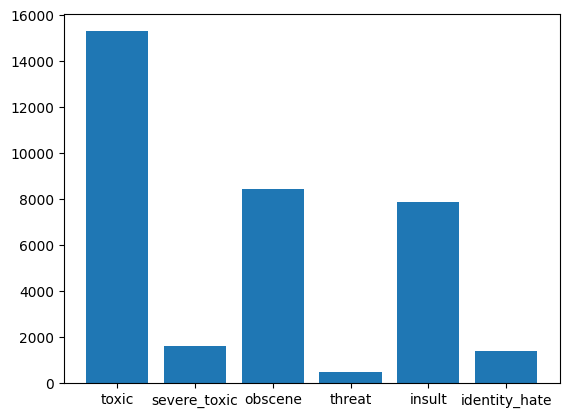

In [13]:
plt.bar(comments.index,comments)

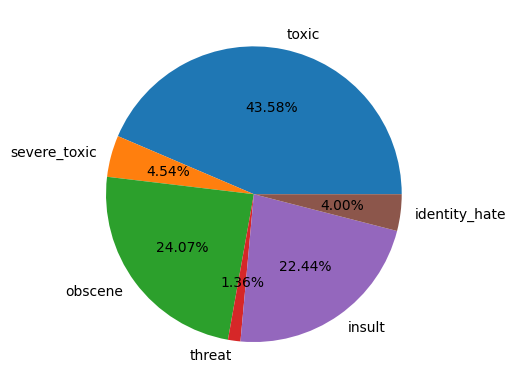

In [17]:
plt.pie(comments, labels=comments.index, autopct='%2.2f%%');

In [19]:
total=df.sum(numeric_only=True,axis=1)

In [20]:
sum(total!=0)

16225

In [29]:
newdf=pd.DataFrame({
    'neutral':[sum(total == 0)],
    'toxic':[sum(total != 0)]
})

In [30]:
newdf

,neutral,toxic
0,143346,16225


In [31]:
newdf.T

,0
neutral,143346
toxic,16225


### Data cleaning

In [37]:
import re

In [43]:
def clean_text(text):
    text=text.lower()
    text=re.sub(r'[^a-z0-9]+',' ',text)
    return text

In [44]:
sample_text="hello how are you?"


In [45]:
clean_text(sample_text)

'hello how are you '

In [55]:
## DEFINE INPUT VARIABLE
comments=df['comment_text']
labels=df.drop(['id','comment_text'],axis=1)

In [56]:
comments_text = comments.apply(clean_text)

In [57]:
comments_text

0         explanation why the edits made under my userna...
1         d aww he matches this background colour i m se...
2         hey man i m really not trying to edit war it s...
3          more i can t make any real suggestions on imp...
4         you sir are my hero any chance you remember wh...
                                ...                        
159566     and for the second time of asking when your v...
159567    you should be ashamed of yourself that is a ho...
159568    spitzer umm theres no actual article for prost...
159569    and it looks like it was actually you who put ...
159570     and i really don t think you understand i cam...
Name: comment_text, Length: 159571, dtype: object

#### Prepare Input Data

In [53]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Dense, Embedding, LSTM, GRU
from sklearn.model_selection import train_test_split


In [58]:
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(comments_text)
sequences = tokenizer.texts_to_sequences(comments_text)
padded = pad_sequences(sequences, maxlen=150, padding='post')

In [59]:
padded.shape

(159571, 150)

In [60]:
padded

array([[ 678,   77,    1, ...,    0,    0,    0],
       [ 161,   51, 2619, ...,    0,    0,    0],
       [ 407,  417,    3, ...,    0,    0,    0],
       ...,
       [7313, 5171,   48, ...,    0,    0,    0],
       [   5,   10,  568, ...,    0,    0,    0],
       [   5,    3,  137, ...,    0,    0,    0]])

#### Cross Validation

In [61]:
x_train,x_test,y_train,y_test = train_test_split(padded, labels, random_state=0,test_size=0.2)

In [62]:
x_train.shape, y_train.shape

((127656, 150), (127656, 6))

In [63]:
x_test.shape,y_test.shape

((31915, 150), (31915, 6))

In [64]:
model = Sequential()
# 1. Update input_length to 150 to match your padded sequences (maxlen=150)
model.add(Embedding(10000, 100, input_length=150)) 
model.add(GRU(128))
# 2. Set units to 6 (for your 6 labels) and activation to 'sigmoid' for multi-label classification
model.add(Dense(6, activation='sigmoid'))

In [66]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

#### Train the model

In [67]:
model.fit(x_train,y_train, epochs=3,validation_data=(x_test,y_test))

Epoch 1/3


3990/3990 [==============================] - 507s 126ms/step - loss: 0.0724 - accuracy: 0.9868 - val_loss: 0.0503 - val_accuracy: 0.9936
Epoch 2/3
3990/3990 [==============================] - 504s 126ms/step - loss: 0.0448 - accuracy: 0.9889 - val_loss: 0.0486 - val_accuracy: 0.9851
Epoch 3/3
3990/3990 [==============================] - 504s 126ms/step - loss: 0.0391 - accuracy: 0.9874 - val_loss: 0.0484 - val_accuracy: 0.9867


In [76]:
sample1 = 'You are stupid. No one cares about your opinion. Just shut up.'
sample2 = 'You are waste of time. World is better without you.'
sample3 = "Your life will be so beautiful with her."

In [79]:
def predict(new_comment):
    cleaned = clean_text(new_comment)
    new_seq = tokenizer.texts_to_sequences([cleaned])
    new_pad = pad_sequences(new_seq, maxlen=150)
    prediction = model.predict(new_pad, verbose=False)
    for i in range(len(prediction[0])):
        if prediction[0][i] > 0.5:
            print(toxicities[i])
    return prediction

In [80]:
toxicities = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

In [81]:
predict(sample1)

array([[0.39346972, 0.02506437, 0.16635501, 0.00437412, 0.15980941,
        0.01815225]], dtype=float32)